<a href="https://colab.research.google.com/github/Thrinadh-25/safestreet/blob/v1/vit88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:




from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import ViTForImageClassification, ViTFeatureExtractor, get_cosine_schedule_with_warmup
import torchvision.transforms as T


# --- Helper: parse XML annotations ---
def parse_annotation(annotation_path):
    from xml.etree import ElementTree
    tree = ElementTree.parse(annotation_path)
    root = tree.getroot()
    image_info = {
        'filename': root.find('filename').text,
        'objects': []
    }
    for obj in root.iter('object'):
        cls_name = obj.find('name').text.strip().upper()
        xmlbox = obj.find('bndbox')
        xmin = int(xmlbox.find('xmin').text)
        xmax = int(xmlbox.find('xmax').text)
        ymin = int(xmlbox.find('ymin').text)
        ymax = int(xmlbox.find('ymax').text)
        image_info['objects'].append({'class': cls_name, 'bbox': [xmin, ymin, xmax, ymax]})
    return image_info



# --- Load dataset from india/train ---
SEVERITY_THRESHOLDS = {
    'low': 0.01,
    'medium': 0.05
}

def load_india_train_dataset(base_path):
    annotations_dir = os.path.join(base_path, 'india', 'train')
    images_dir = os.path.join(base_path, 'india', 'train')
    VALID_CLASSES = {"D00", "D01", "D10", "D11", "D20", "D40", "D43", "D44"}

    data = []
    for f in os.listdir(annotations_dir):
        if not f.endswith('.xml'): continue
        annotation_path = os.path.join(annotations_dir, f)
        image_info = parse_annotation(annotation_path)
        image_path = os.path.join(images_dir, image_info['filename'])
        if not os.path.exists(image_path) or not image_info['objects']:
            continue
        classes = [obj['class'] for obj in image_info['objects'] if obj['class'] in VALID_CLASSES]
        if not classes:
            continue
        dominant_class = max(set(classes), key=classes.count)

        image = Image.open(image_path)
        w, h = image.size
        image_area = w * h
        max_area = 0
        for obj in image_info['objects']:
            xmin, ymin, xmax, ymax = obj['bbox']
            area = (xmax - xmin) * (ymax - ymin)
            max_area = max(max_area, area / image_area)

        if max_area < SEVERITY_THRESHOLDS['low']:
            severity = 'low'
        elif max_area < SEVERITY_THRESHOLDS['medium']:
            severity = 'medium'
        else:
            severity = 'high'

        data.append({
            'image_path': image_path,
            'classification_label': dominant_class,
            'severity_label': severity,
            'detection_objects': image_info['objects']
        })
    return pd.DataFrame(data)



# --- Balance dataset by oversampling ---
def balance_dataset(df):
    max_count = df['classification_label'].value_counts().max()
    balanced_dfs = []
    for label in df['classification_label'].unique():
        label_df = df[df['classification_label'] == label]
        label_df_oversampled = pd.concat([label_df] * (max_count // len(label_df)), ignore_index=True)
        if max_count % len(label_df):
            label_df_oversampled = pd.concat([label_df_oversampled, label_df.sample(max_count % len(label_df))], ignore_index=True)
        balanced_dfs.append(label_df_oversampled)
    return pd.concat(balanced_dfs, ignore_index=True).sample(frac=1).reset_index(drop=True)

# --- Custom Dataset ---
class DamageDataset(Dataset):
    def __init__(self, dataframe, feature_extractor):
        self.dataframe = dataframe
        self.feature_extractor = feature_extractor
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.2, 0.2, 0.2, 0.2),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = row['label_encoded']
        severity = row['severity_encoded']
        boxes = [obj['bbox'] for obj in row['detection_objects']]
        orig_width, orig_height = image.size
        norm_boxes = [[xmin/orig_width, ymin/orig_height, xmax/orig_width, ymax/orig_height] for xmin,ymin,xmax,ymax in boxes]
        image = self.transform(image)
        inputs = self.feature_extractor(images=image, return_tensors="pt", do_rescale=False)
        inputs = {k: v.squeeze(0) for k,v in inputs.items()}
        inputs["labels"] = label
        inputs["severity"] = severity
        inputs["normalized_boxes"] = norm_boxes
        return inputs



# --- Model ---
class DamageViTModel(nn.Module):
    def __init__(self, num_classes, num_severity):
        super().__init__()
        self.vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224-in21k", num_labels=num_classes, ignore_mismatched_sizes=True)
        for param in self.vit.vit.encoder.layer[-2:].parameters(): param.requires_grad = True
        for param in self.vit.classifier.parameters(): param.requires_grad = True
        self.bbox_regressor = nn.Sequential(nn.Linear(self.vit.config.hidden_size, 256), nn.ReLU(), nn.Linear(256, 4))
        self.severity_classifier = nn.Sequential(nn.Linear(self.vit.config.hidden_size, 128), nn.ReLU(), nn.Linear(128, num_severity))

    def forward(self, pixel_values, labels=None, severity=None):
        outputs = self.vit(pixel_values=pixel_values, labels=labels, output_hidden_states=True)
        cls_token = outputs.hidden_states[-1][:, 0]
        bbox_pred = torch.sigmoid(self.bbox_regressor(cls_token))
        severity_logits = self.severity_classifier(cls_token)
        return {
            'class_logits': outputs.logits,
            'bbox_pred': bbox_pred,
            'severity_logits': severity_logits,
            'loss': outputs.loss if labels is not None else None
        }

# --- Loss ---
class DamageLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.cls_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.sev_loss = nn.CrossEntropyLoss()
        self.bbox_loss = nn.SmoothL1Loss()

    def forward(self, pred, targets):
        cls_loss = self.cls_loss(pred['class_logits'], targets['labels'])
        sev_loss = self.sev_loss(pred['severity_logits'], targets['severity'])
        bbox_target = torch.tensor([b[0] for b in targets['normalized_boxes']]).to(pred['bbox_pred'].device)
        bbox_loss = self.bbox_loss(pred['bbox_pred'], bbox_target)
        return cls_loss + bbox_loss + sev_loss, cls_loss, bbox_loss, sev_loss



# --- Prepare & Launch Training ---
df = load_india_train_dataset("/content/drive/MyDrive/dataset")
df['classification_label'] = df['classification_label'].str.strip().str.upper()
df = df[df['classification_label'].isin(["D00", "D01", "D10", "D11", "D20", "D40", "D43", "D44"])]
df = balance_dataset(df)
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['classification_label'])
df['severity_label'] = df['severity_label'].str.lower()
severity_le = LabelEncoder()
df['severity_encoded'] = severity_le.fit_transform(df['severity_label'])
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)



# --- Train Model ---
def train_model(train_df, val_df, num_classes, severity_classes, label_encoder, num_epochs=10):
    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    def collate_fn(batch):
        return {
            'pixel_values': torch.stack([d['pixel_values'] for d in batch]),
            'labels': torch.tensor([d['labels'] for d in batch]),
            'severity': torch.tensor([d['severity'] for d in batch]),
            'normalized_boxes': [d['normalized_boxes'] for d in batch]
        }

    train_loader = DataLoader(DamageDataset(train_df, extractor), batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn)
    val_loader = DataLoader(DamageDataset(val_df, extractor), batch_size=16, shuffle=False, num_workers=2, collate_fn=collate_fn)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DamageViTModel(num_classes, severity_classes).to(device)
    criterion = DamageLoss()
    optimizer = optim.AdamW(model.parameters(), lr=5e-5)
    scheduler = get_cosine_schedule_with_warmup(optimizer, 200, num_epochs * len(train_loader))
    best_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        model.train()
        train_loss, cls_loss, bbox_loss, sev_loss = 0, 0, 0, 0
        loop = tqdm(train_loader, desc="Training")
        for batch in loop:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            severity = batch['severity'].to(device)
            targets = {'labels': labels, 'severity': severity, 'normalized_boxes': batch['normalized_boxes']}
            optimizer.zero_grad()
            outputs = model(pixel_values, labels, severity)
            loss, c_loss, b_loss, s_loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            cls_loss += c_loss.item()
            bbox_loss += b_loss.item()
            sev_loss += s_loss.item()
            loop.set_postfix(loss=loss.item(), cls=c_loss.item(), bbox=b_loss.item(), severity=s_loss.item())

        print(f"Train Loss: {train_loss/len(train_loader):.4f}, CLS: {cls_loss/len(train_loader):.4f}, BBOX: {bbox_loss/len(train_loader):.4f}, SEV: {sev_loss/len(train_loader):.4f}")
        if train_loss < best_loss:
            best_loss = train_loss
            torch.save(model.state_dict(), "best_damage_vit_model.pth")
            print("Saving best model...")

train_model(train_df, val_df, len(le.classes_), len(severity_le.classes_), le, num_epochs=30)


Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7864845b6020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7864845b6020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss: 0.3613, CLS: 0.3560, BBOX: 0.0039, SEV: 0.0013
Saving best model...
Epoch 30/30


Training:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss: 0.3613, CLS: 0.3562, BBOX: 0.0038, SEV: 0.0013


In [ ]:
# Add this visualization function to your script
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_damage(row, severity=None):
    img = Image.open(row['image_path']).convert("RGB")
    w, h = img.size
    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)

    for obj in row['detection_objects']:
        xmin, ymin, xmax, ymax = obj['bbox']
        width, height = xmax - xmin, ymax - ymin
        area = width * height / (w * h)

        if area < 0.01:
            sev = 'low'
            color = 'lime'
        elif area < 0.05:
            sev = 'medium'
            color = 'orange'
        else:
            sev = 'high'
            color = 'red'

        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f"{obj['class']} ({sev})", color=color, fontsize=10, weight='bold')

    ax.set_title(f"Predicted Severity: {severity if severity else row['severity_label'].upper()}", fontsize=14)
    plt.axis('off')
    plt.show()


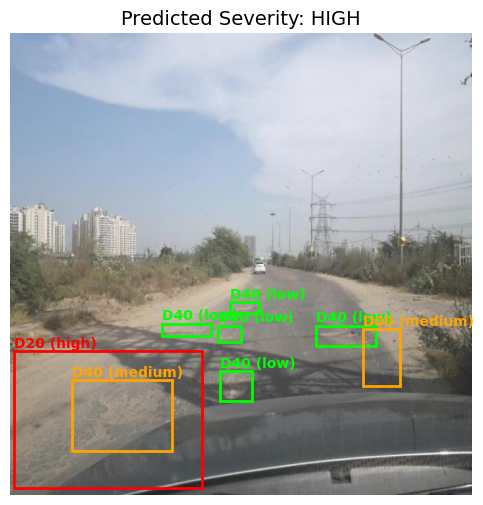

In [ ]:
# Example: visualize a random validation sample
sample = val_df.sample(1).iloc[0]
visualize_damage(sample)


In [ ]:
# Add this test_model function below your train_model()
from sklearn.metrics import classification_report, accuracy_score

def test_model(model, test_df, label_encoder, severity_encoder):
    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    def collate_fn(batch):
        return {
            'pixel_values': torch.stack([d['pixel_values'] for d in batch]),
            'labels': torch.tensor([d['labels'] for d in batch]),
            'severity': torch.tensor([d['severity'] for d in batch]),
            'normalized_boxes': [d['normalized_boxes'] for d in batch]
        }

    test_loader = DataLoader(DamageDataset(test_df, extractor), batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_fn)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    all_preds, all_labels = [], []
    all_sev_preds, all_sev_labels = [], []
    all_bbox_preds, all_bbox_targets = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            severity = batch['severity'].to(device)
            targets = {'labels': labels, 'severity': severity, 'normalized_boxes': batch['normalized_boxes']}
            outputs = model(pixel_values)

            pred_classes = torch.argmax(outputs['class_logits'], dim=1)
            pred_severity = torch.argmax(outputs['severity_logits'], dim=1)

            all_preds.extend(pred_classes.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_sev_preds.extend(pred_severity.cpu().numpy())
            all_sev_labels.extend(severity.cpu().numpy())
            all_bbox_preds.extend(outputs['bbox_pred'].cpu().numpy())
            all_bbox_targets.extend([b[0] for b in batch['normalized_boxes']])

    cls_acc = accuracy_score(all_labels, all_preds)
    sev_acc = accuracy_score(all_sev_labels, all_sev_preds)

    print("\n=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

    print("\n=== Severity Report ===")
    print(classification_report(all_sev_labels, all_sev_preds, target_names=severity_encoder.classes_))

    # Compute mean IoU
    ious = []
    for pred_box, true_box in zip(all_bbox_preds, all_bbox_targets):
        x1p, y1p, x2p, y2p = pred_box
        x1t, y1t, x2t, y2t = true_box
        xA, yA = max(x1p, x1t), max(y1p, y1t)
        xB, yB = min(x2p, x2t), min(y2p, y2t)
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = max(0, x2p - x1p) * max(0, y2p - y1p)
        boxBArea = max(0, x2t - x1t) * max(0, y2t - y1t)
        unionArea = boxAArea + boxBArea - interArea
        iou = interArea / unionArea if unionArea else 0
        ious.append(iou)

    print(f"\n=== Accuracy ===")
    print(f"Damage Class Accuracy: {cls_acc:.4f}")
    print(f"Severity Accuracy:     {sev_acc:.4f}")
    print(f"Mean IoU:              {np.mean(ious):.4f}")

# Example usage after training:
# Example usage after training:
model = DamageViTModel(num_classes=len(le.classes_), num_severity=len(severity_le.classes_))
model.load_state_dict(torch.load("best_damage_vit_model.pth"), strict=False)
test_model(model, test_df, le, severity_le)



Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing:   0%|          | 0/18 [00:00<?, ?it/s]


=== Classification Report ===
              precision    recall  f1-score   support

         D00       0.87      0.92      0.89        63
         D10       1.00      1.00      1.00        82
         D20       0.82      0.79      0.80        70
         D40       0.83      0.82      0.83        73

    accuracy                           0.89       288
   macro avg       0.88      0.88      0.88       288
weighted avg       0.88      0.89      0.88       288


=== Severity Report ===
              precision    recall  f1-score   support

        high       0.84      0.84      0.84       115
         low       0.90      0.49      0.63        37
      medium       0.79      0.89      0.84       136

    accuracy                           0.82       288
   macro avg       0.84      0.74      0.77       288
weighted avg       0.83      0.82      0.81       288


=== Accuracy ===
Damage Class Accuracy: 0.8854
Severity Accuracy:     0.8194
Mean IoU:              0.2664


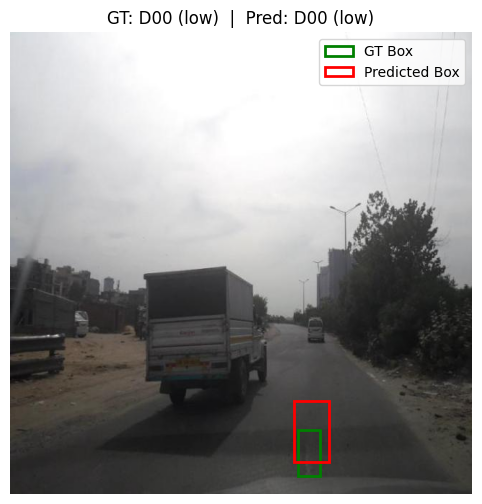

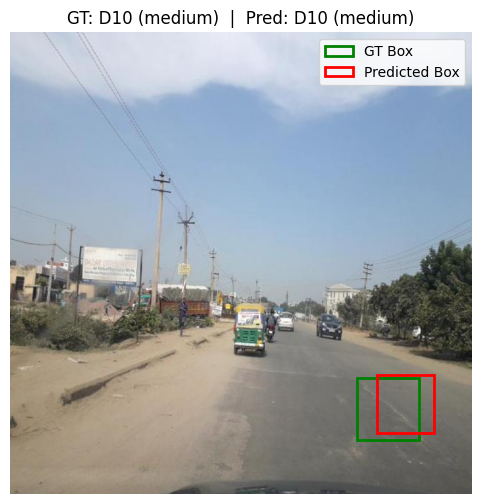

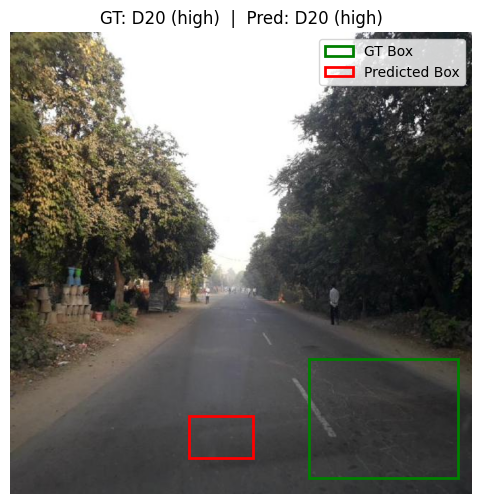

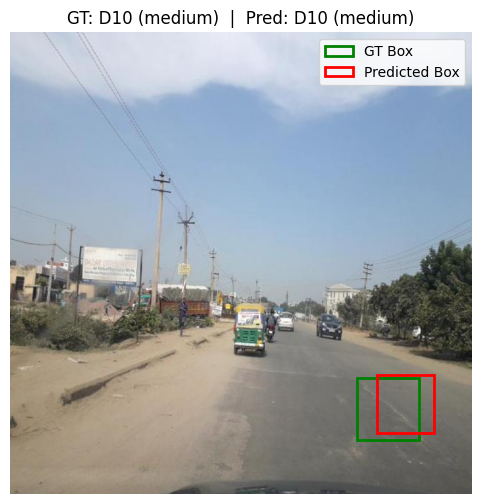

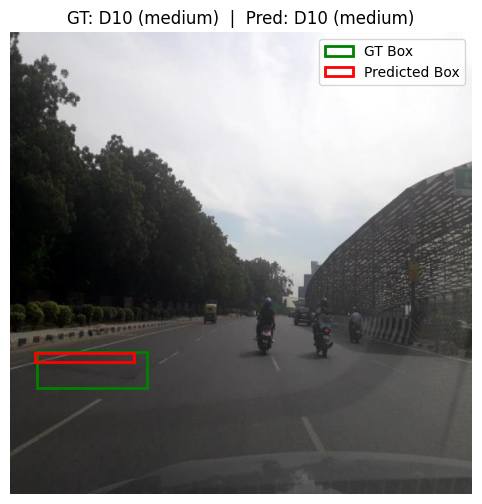

In [ ]:
# Add this to your script for test prediction visualization

def visualize_prediction(row, model, label_encoder, severity_encoder):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(row['image_path']).convert("RGB")
    w, h = image.size
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor()
    ])
    processed_image = transform(image)

    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    inputs = extractor(images=processed_image, return_tensors="pt", do_rescale=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred_class = torch.argmax(outputs['class_logits'], dim=1).item()
        pred_severity = torch.argmax(outputs['severity_logits'], dim=1).item()
        pred_box = outputs['bbox_pred'][0].cpu().numpy()

    # Denormalize bbox
    x1 = int(pred_box[0] * w)
    y1 = int(pred_box[1] * h)
    x2 = int(pred_box[2] * w)
    y2 = int(pred_box[3] * h)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    # Ground truth box (first only)
    if row['detection_objects']:
        gt_box = row['detection_objects'][0]['bbox']
        rect_gt = patches.Rectangle(
            (gt_box[0], gt_box[1]), gt_box[2] - gt_box[0], gt_box[3] - gt_box[1],
            linewidth=2, edgecolor='green', facecolor='none', label='GT Box'
        )
        ax.add_patch(rect_gt)

    # Predicted box
    rect_pred = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none', label='Predicted Box'
    )
    ax.add_patch(rect_pred)

    # Legends
    ax.legend(loc='upper right')
    ax.set_title(f"GT: {row['classification_label']} ({row['severity_label']})  |  Pred: {label_encoder.classes_[pred_class]} ({severity_encoder.classes_[pred_severity]})")
    plt.axis('off')
    plt.show()

# Example usage:
for _ in range(5):
    sample = test_df.sample(1).iloc[0]
    visualize_prediction(sample, model, le, severity_le)


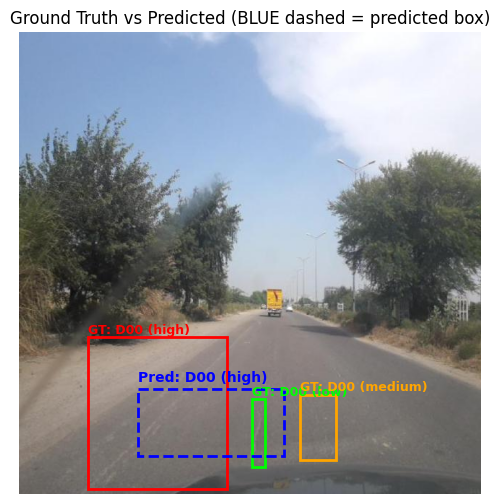

In [ ]:


def visualize_test_with_prediction(row, model, label_encoder, severity_encoder):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(row['image_path']).convert("RGB")
    w, h = image.size
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor()
    ])
    processed_image = transform(image)

    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    inputs = extractor(images=processed_image, return_tensors="pt", do_rescale=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred_class = torch.argmax(outputs['class_logits'], dim=1).item()
        pred_severity = torch.argmax(outputs['severity_logits'], dim=1).item()
        pred_box = outputs['bbox_pred'][0].cpu().numpy()

    x1 = int(pred_box[0] * w)
    y1 = int(pred_box[1] * h)
    x2 = int(pred_box[2] * w)
    y2 = int(pred_box[3] * h)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    # --- Draw ground-truth boxes ---
    for obj in row['detection_objects']:
        xmin, ymin, xmax, ymax = obj['bbox']
        width, height = xmax - xmin, ymax - ymin
        area_ratio = (width * height) / (w * h)
        if area_ratio < 0.01:
            color = 'lime'
            severity = 'low'
        elif area_ratio < 0.05:
            color = 'orange'
            severity = 'medium'
        else:
            color = 'red'
            severity = 'high'
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f"GT: {obj['class']} ({severity})", color=color, fontsize=9, weight='bold')

    # --- Draw predicted box ---
    rect_pred = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='blue', facecolor='none', linestyle='--'
    )
    ax.add_patch(rect_pred)
    ax.text(x1, y1 - 10, f"Pred: {label_encoder.classes_[pred_class]} ({severity_encoder.classes_[pred_severity]})", color='blue', fontsize=10, weight='bold')

    ax.set_title("Ground Truth vs Predicted (BLUE dashed = predicted box)")
    plt.axis('off')
    plt.show()

# Example:
visualize_test_with_prediction(test_df.sample(1).iloc[0], model, le, severity_le)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms as T
from transformers import ViTFeatureExtractor

def visualize_prediction_on_image(image_path, model, label_encoder, severity_encoder):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor()
    ])
    processed_image = transform(image)

    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    inputs = extractor(images=processed_image, return_tensors="pt", do_rescale=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred_class = torch.argmax(outputs['class_logits'], dim=1).item()
        pred_severity = torch.argmax(outputs['severity_logits'], dim=1).item()
        pred_box = outputs['bbox_pred'][0].cpu().numpy()

    x1 = int(pred_box[0] * w)
    y1 = int(pred_box[1] * h)
    x2 = int(pred_box[2] * w)
    y2 = int(pred_box[3] * h)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    rect_pred = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none', label='Predicted Box'
    )
    ax.add_patch(rect_pred)

    ax.legend(loc='upper right')
    ax.set_title(f"Predicted: {label_encoder.classes_[pred_class]} ({severity_encoder.classes_[pred_severity]})")
    plt.axis('off')
    plt.show()

# Single image usage from Google Drive in Colab
image_path = "/content/drive/MyDrive/dataset/valid/test image.jpg"
visualize_prediction_on_image(image_path, model, le, severity_le)


NameError: name 'model' is not defined

In [ ]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms as T
from transformers import ViTFeatureExtractor

# Your model class definition placeholder (replace with actual one)
class RoadDamageModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Define model layers matching training architecture
        pass

    def forward(self, **inputs):
        # Implement your forward pass returning:
        # {'class_logits': ..., 'severity_logits': ..., 'bbox_pred': ...}
        pass

# Load the best model weights
model_path = "/content/drive/MyDrive/best_damage_vit_model (1).pth"
model = RoadDamageModel()
model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))

# Assume encoders are already loaded or stubbed
# Replace with actual loading logic if needed
le = ...  # Label encoder (classification)
severity_le = ...  # Severity encoder

def visualize_prediction_on_image(image_path, model, label_encoder, severity_encoder):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor()
    ])
    processed_image = transform(image)

    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    inputs = extractor(images=processed_image, return_tensors="pt", do_rescale=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred_class = torch.argmax(outputs['class_logits'], dim=1).item()
        pred_severity = torch.argmax(outputs['severity_logits'], dim=1).item()
        pred_box = outputs['bbox_pred'][0].cpu().numpy()

    x1 = int(pred_box[0] * w)
    y1 = int(pred_box[1] * h)
    x2 = int(pred_box[2] * w)
    y2 = int(pred_box[3] * h)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    rect_pred = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none', label='Predicted Box'
    )
    ax.add_patch(rect_pred)

    ax.legend(loc='upper right')
    ax.set_title(f"Predicted: {label_encoder.classes_[pred_class]} ({severity_encoder.classes_[pred_severity]})")
    plt.axis('off')
    plt.show()

# Run prediction on single image from Google Drive
image_path = "/content/drive/MyDrive/dataset/valid/test image.jpg"
visualize_prediction_on_image(image_path, model, le, severity_le)

RuntimeError: Error(s) in loading state_dict for RoadDamageModel:
	Unexpected key(s) in state_dict: "vit.vit.embeddings.cls_token", "vit.vit.embeddings.position_embeddings", "vit.vit.embeddings.patch_embeddings.projection.weight", "vit.vit.embeddings.patch_embeddings.projection.bias", "vit.vit.encoder.layer.0.attention.attention.query.weight", "vit.vit.encoder.layer.0.attention.attention.query.bias", "vit.vit.encoder.layer.0.attention.attention.key.weight", "vit.vit.encoder.layer.0.attention.attention.key.bias", "vit.vit.encoder.layer.0.attention.attention.value.weight", "vit.vit.encoder.layer.0.attention.attention.value.bias", "vit.vit.encoder.layer.0.attention.output.dense.weight", "vit.vit.encoder.layer.0.attention.output.dense.bias", "vit.vit.encoder.layer.0.intermediate.dense.weight", "vit.vit.encoder.layer.0.intermediate.dense.bias", "vit.vit.encoder.layer.0.output.dense.weight", "vit.vit.encoder.layer.0.output.dense.bias", "vit.vit.encoder.layer.0.layernorm_before.weight", "vit.

In [ ]:
import os
import torch
import pickle
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms as T
from transformers import ViTFeatureExtractor, ViTModel
import torch.nn as nn

# Define model class
class RoadDamageModel(nn.Module):
    def __init__(self, num_classes, num_severities):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        hidden_size = self.vit.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.severity = nn.Linear(hidden_size, num_severities)
        self.bbox = nn.Linear(hidden_size, 4)

    def forward(self, **inputs):
        outputs = self.vit(**inputs)
        pooled = outputs.pooler_output
        return {
            'class_logits': self.classifier(pooled),
            'severity_logits': self.severity(pooled),
            'bbox_pred': self.bbox(pooled)
        }

# Load label encoders
with open("/content/drive/MyDrive/models/le.pkl", "rb") as f:
    le = pickle.load(f)
with open("/content/drive/MyDrive/models/severity_le.pkl", "rb") as f:
    severity_le = pickle.load(f)

# Load model
model_path = "/content/drive/MyDrive/best_damage_vit_model (1).pth"
model = RoadDamageModel(num_classes=len(le.classes_), num_severities=len(severity_le.classes_))
model.load_state_dict(torch.load(model_path, map_location="cpu"))

# Visualize prediction on a single image
def visualize_prediction_on_image(image_path, model, label_encoder, severity_encoder):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor()
    ])
    processed_image = transform(image)

    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    inputs = extractor(images=processed_image, return_tensors="pt", do_rescale=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred_class = torch.argmax(outputs['class_logits'], dim=1).item()
        pred_severity = torch.argmax(outputs['severity_logits'], dim=1).item()
        pred_box = outputs['bbox_pred'][0].cpu().numpy()

    x1 = int(pred_box[0] * w)
    y1 = int(pred_box[1] * h)
    x2 = int(pred_box[2] * w)
    y2 = int(pred_box[3] * h)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    rect_pred = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none', label='Predicted Box'
    )
    ax.add_patch(rect_pred)

    ax.legend(loc='upper right')
    ax.set_title(f"Predicted: {label_encoder.classes_[pred_class]} ({severity_encoder.classes_[pred_severity]})")
    plt.axis('off')
    plt.show()

# Predict single image
image_path = "/content/drive/MyDrive/dataset/valid/test image.jpg"
visualize_prediction_on_image(image_path, model, le, severity_le)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/models/le.pkl'

In [ ]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms as T
from transformers import ViTFeatureExtractor, ViTModel
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder

# Manually define label encoders
class_labels = ['D00', 'D01', 'D10', 'D11', 'D20', 'D40']
severity_labels = ['low', 'moderate', 'high']

le = LabelEncoder()
le.fit(class_labels)

severity_le = LabelEncoder()
severity_le.fit(severity_labels)

# Define model class
class RoadDamageModel(nn.Module):
    def __init__(self, num_classes, num_severities):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        hidden_size = self.vit.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.severity = nn.Linear(hidden_size, num_severities)
        self.bbox = nn.Linear(hidden_size, 4)

    def forward(self, **inputs):
        outputs = self.vit(**inputs)
        pooled = outputs.pooler_output
        return {
            'class_logits': self.classifier(pooled),
            'severity_logits': self.severity(pooled),
            'bbox_pred': self.bbox(pooled)
        }

# Load model
model_path = "/content/drive/MyDrive/best_damage_vit_model (1).pth"
model = model = RoadDamageModel(num_classes=4, num_severities=3)


model.load_state_dict(torch.load(model_path, map_location="cpu"))

# Visualize prediction on a single image
def visualize_prediction_on_image(image_path, model, label_encoder, severity_encoder):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor()
    ])
    processed_image = transform(image)

    extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
    inputs = extractor(images=processed_image, return_tensors="pt", do_rescale=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred_class = torch.argmax(outputs['class_logits'], dim=1).item()
        pred_severity = torch.argmax(outputs['severity_logits'], dim=1).item()
        pred_box = outputs['bbox_pred'][0].cpu().numpy()

    x1 = int(pred_box[0] * w)
    y1 = int(pred_box[1] * h)
    x2 = int(pred_box[2] * w)
    y2 = int(pred_box[3] * h)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(image)

    rect_pred = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none', label='Predicted Box'
    )
    ax.add_patch(rect_pred)

    ax.legend(loc='upper right')
    ax.set_title(f"Predicted: {label_encoder.classes_[pred_class]} ({severity_encoder.classes_[pred_severity]})")
    plt.axis('off')
    plt.show()

# Predict single image
image_path = "/content/drive/MyDrive/dataset/valid/test image.jpg"
visualize_prediction_on_image(image_path, model, le, severity_le)



RuntimeError: Error(s) in loading state_dict for RoadDamageModel:
	Missing key(s) in state_dict: "vit.embeddings.cls_token", "vit.embeddings.position_embeddings", "vit.embeddings.patch_embeddings.projection.weight", "vit.embeddings.patch_embeddings.projection.bias", "vit.encoder.layer.0.attention.attention.query.weight", "vit.encoder.layer.0.attention.attention.query.bias", "vit.encoder.layer.0.attention.attention.key.weight", "vit.encoder.layer.0.attention.attention.key.bias", "vit.encoder.layer.0.attention.attention.value.weight", "vit.encoder.layer.0.attention.attention.value.bias", "vit.encoder.layer.0.attention.output.dense.weight", "vit.encoder.layer.0.attention.output.dense.bias", "vit.encoder.layer.0.intermediate.dense.weight", "vit.encoder.layer.0.intermediate.dense.bias", "vit.encoder.layer.0.output.dense.weight", "vit.encoder.layer.0.output.dense.bias", "vit.encoder.layer.0.layernorm_before.weight", "vit.encoder.layer.0.layernorm_before.bias", "vit.encoder.layer.0.layernorm_

In [ ]:
from transformers import ViTForImageClassification

class DamageViTModel(nn.Module):
    def __init__(self, num_classes, num_severities):
        super().__init__()
        self.vit = ViTForImageClassification.from_pretrained(
            "google/vit-base-patch16-224-in21k",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )
        for param in self.vit.vit.encoder.layer[-2:].parameters():
            param.requires_grad = True
        for param in self.vit.classifier.parameters():
            param.requires_grad = True

        self.bbox_regressor = nn.Sequential(
            nn.Linear(self.vit.config.hidden_size, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )
        self.severity_classifier = nn.Sequential(
            nn.Linear(self.vit.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_severities)
        )

    def forward(self, pixel_values, labels=None, severity=None):
        outputs = self.vit(pixel_values=pixel_values, labels=labels, output_hidden_states=True)
        cls_token = outputs.hidden_states[-1][:, 0]
        return {
            'class_logits': outputs.logits,
            'bbox_pred': torch.sigmoid(self.bbox_regressor(cls_token)),
            'severity_logits': self.severity_classifier(cls_token),
            'loss': outputs.loss if labels is not None else None
        }


In [ ]:
model = DamageViTModel(num_classes=4, num_severities=3)
model.load_state_dict(torch.load(model_path, map_location="cpu"))


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


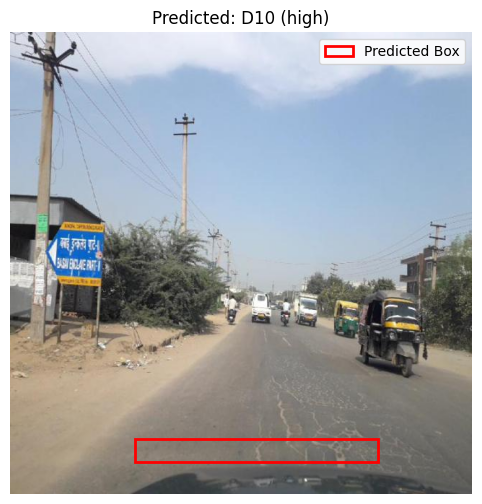

In [ ]:
image_path = "/content/drive/MyDrive/dataset/india/valid/test image.jpg"
visualize_prediction_on_image(image_path, model, le, severity_le)


In [ ]:
import torch
state = torch.load("/content/drive/MyDrive/best_damage_vit_model (1).pth", map_location="cpu")
weight = state.get("vit.classifier.weight")
bias = state.get("vit.classifier.bias")
print("Classifier weight shape:", weight.shape if weight is not None else None)
print("Classifier bias shape:", bias.shape if bias is not None else None)


Classifier weight shape: torch.Size([4, 768])
Classifier bias shape: torch.Size([4])


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dataset/your_training_labels.csv")
df['classification_label'] = df['classification_label'].str.strip().str.upper()
print(df['classification_label'].value_counts())


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset/your_training_labels.csv'

In [ ]:
from collections import Counter
from xml.etree import ElementTree
import os

annotation_dir = "/content/drive/MyDrive/dataset/india/train"
label_counter = Counter()

for fname in os.listdir(annotation_dir):
    if fname.endswith(".xml"):
        tree = ElementTree.parse(os.path.join(annotation_dir, fname))
        for obj in tree.findall(".//object"):
            cls = obj.find("name").text.strip().upper()
            label_counter[cls] += 1

print(label_counter.most_common(10))  # Shows top 10 classes by frequency


[('D40', 791), ('D20', 559), ('D60', 416), ('D00', 415), ('D10', 27), ('D50', 24), ('D70', 9), ('D80', 3)]
